In [1]:
# Установка необходимых библиотек (только для Google Colab)
!pip install -q sentence-transformers umap-learn seaborn joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.6 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sentence_transformers import SentenceTransformer
import umap

# Глобальные переменные
RANDOM_STATE = 42
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]


In [3]:
import urllib.request
import tarfile

def download_ag_news(target_dir="data"):
    url = "https://s3.amazonaws.com/fast-ai-nlp/ag_news_csv.tgz"
    dest = Path(target_dir) / "ag_news_csv.tgz"

    if not dest.exists():
        print("🔽 Скачиваем AG News…")
        os.makedirs(dest.parent, exist_ok=True)
        urllib.request.urlretrieve(url, dest)

    with tarfile.open(dest, "r:gz") as tar:
        tar.extractall(path=dest.parent)

    train_csv = dest.parent / "ag_news_csv" / "train.csv"
    test_csv = dest.parent / "ag_news_csv" / "test.csv"
    return train_csv, test_csv

def load_ag_news(n_samples=None):
    train_csv, _ = download_ag_news()
    df = pd.read_csv(train_csv, header=None, names=["label", "title", "description"])
    df["label"] = df["label"] - 1  # Приводим к 0–3

    if n_samples:
        df = df.sample(n=n_samples, random_state=RANDOM_STATE).reset_index(drop=True)

    return df["title"], df["label"]

# Пример загрузки 10 000 примеров
titles, labels = load_ag_news(n_samples=10_000)
titles[:5]


🔽 Скачиваем AG News…


,title
0,"BBC set for major shake-up, claims newspaper"
1,Marsh averts cash crunch
2,"Jeter, Yankees Look to Take Control (AP)"
3,Flying the Sun to Safety
4,Stocks Seen Flat as Nortel and Oil Weigh


In [4]:
def encode_sbert(sentences, model_name="sentence-transformers/all-MiniLM-L6-v2"):
    print("📐 Векторизация SBERT...")
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        sentences,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    return embeddings

# Пример использования
X_sbert = encode_sbert(titles.tolist())


📐 Векторизация SBERT...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [5]:
# Разделение на обучающую и тестовую выборки
X_train_sbert, X_test_sbert, y_train, y_test = train_test_split(
    X_sbert, labels, test_size=0.2, stratify=labels, random_state=RANDOM_STATE
)

# Обучение логистической регрессии
clf_sbert = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_sbert.fit(X_train_sbert, y_train)

# Предсказание
y_pred_sbert = clf_sbert.predict(X_test_sbert)


🔍 Accuracy SBERT + LogisticRegression: 0.8210

Classification Report:
              precision    recall  f1-score   support

       World       0.85      0.83      0.84       493
      Sports       0.86      0.90      0.88       510
    Business       0.78      0.76      0.77       494
    Sci/Tech       0.79      0.80      0.79       503

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



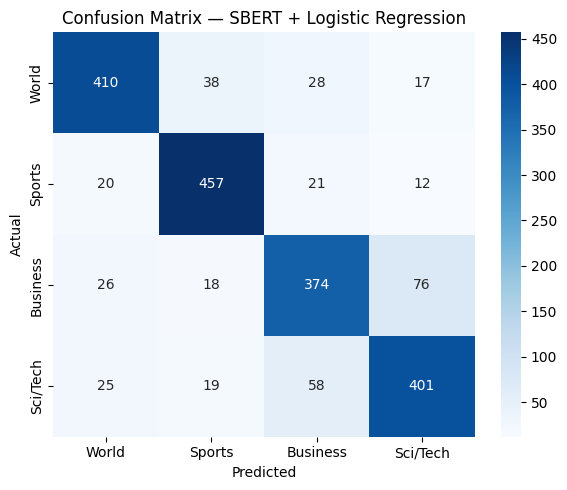

In [6]:
# Accuracy и классификационный отчёт
acc = accuracy_score(y_test, y_pred_sbert)
print(f"🔍 Accuracy SBERT + LogisticRegression: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sbert, target_names=CLASS_NAMES))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_sbert)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SBERT + Logistic Regression")
plt.tight_layout()
plt.show()


🔄 Строим UMAP-проекцию…


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


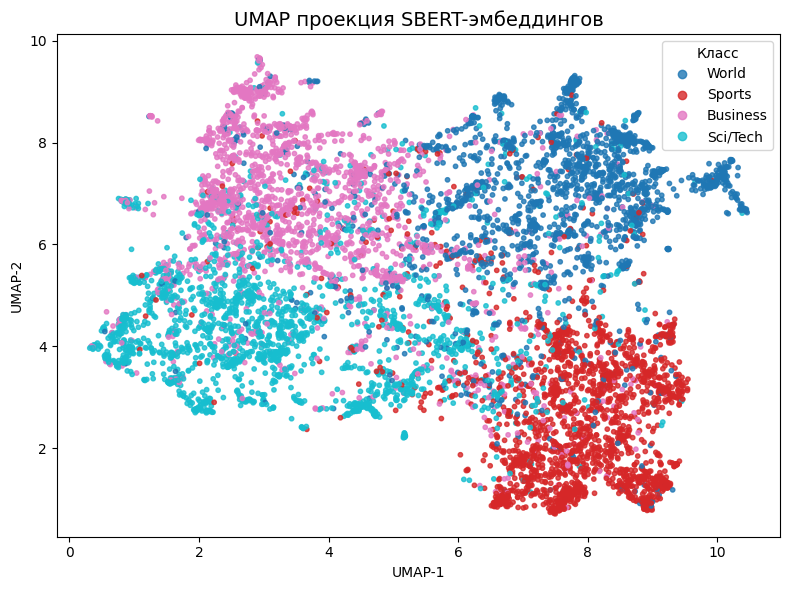

In [7]:
def plot_umap(embeddings, labels):
    reducer = umap.UMAP(random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
    print("🔄 Строим UMAP-проекцию…")
    X_2d = reducer.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", s=10, alpha=0.8)
    plt.title("UMAP проекция SBERT-эмбеддингов", fontsize=14)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(handles=scatter.legend_elements()[0], labels=CLASS_NAMES, title="Класс")
    plt.tight_layout()
    plt.show()

# Визуализируем только тренировочные эмбеддинги
plot_umap(X_train_sbert, y_train)


In [8]:
def encode_tfidf(train_sentences, test_sentences):
    print("📐 Векторизация TF-IDF...")
    vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2))
    X_train = vectorizer.fit_transform(train_sentences)
    X_test = vectorizer.transform(test_sentences)
    return X_train, X_test, vectorizer

# Разделим исходные тексты
X_train_txt, X_test_txt, y_train_tfidf, y_test_tfidf = train_test_split(
    titles, labels, test_size=0.2, stratify=labels, random_state=RANDOM_STATE
)

# Векторизация
X_train_tfidf, X_test_tfidf, tfidf_vectorizer = encode_tfidf(X_train_txt.tolist(), X_test_txt.tolist())


📐 Векторизация TF-IDF...


🔍 Accuracy TF-IDF + LogisticRegression: 0.7930

Classification Report:
              precision    recall  f1-score   support

       World       0.83      0.79      0.81       493
      Sports       0.79      0.86      0.82       510
    Business       0.77      0.77      0.77       494
    Sci/Tech       0.79      0.75      0.77       503

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



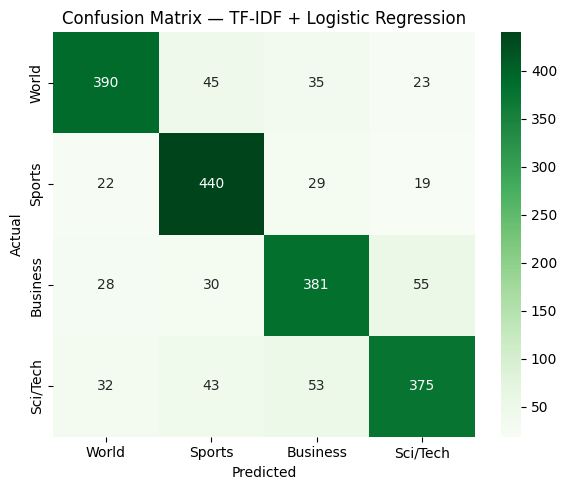

In [9]:
# Обучение модели
clf_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_tfidf.fit(X_train_tfidf, y_train_tfidf)

# Предсказание
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

# Accuracy и отчёт
acc_tfidf = accuracy_score(y_test_tfidf, y_pred_tfidf)
print(f"🔍 Accuracy TF-IDF + LogisticRegression: {acc_tfidf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_tfidf, y_pred_tfidf, target_names=CLASS_NAMES))

# Матрица ошибок
cm_tfidf = confusion_matrix(y_test_tfidf, y_pred_tfidf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Greens", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()


In [10]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Сохраняем модели
joblib.dump(clf_sbert, "models/sbert_model.joblib")
joblib.dump(clf_tfidf, "models/tfidf_model.joblib")
joblib.dump(tfidf_vectorizer, "models/tfidf_vectorizer.joblib")

print("✅ Модели сохранены в папку models/")

✅ Модели сохранены в папку models/
